<a href="https://colab.research.google.com/github/kolden0/KNURE/blob/main/pokemon_by_koldenl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("Libraries imported successfully!")


Libraries imported successfully!


---
# Section 3: Cleaning Data

## 3.1 Load & Diagnose Data

We start by loading the dataset and inspecting it with `head()`, `tail()`, `columns`, `shape`, and `info()`.


In [ ]:
# Load all three datasets
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')
tests   = pd.read_csv('tests.csv')

print("=== pokemon.csv ===")
print(f"Shape: {pokemon.shape}")
pokemon.head()


=== pokemon.csv ===
Shape: (800, 12)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [ ]:
# tail() — last 5 rows
pokemon.tail()


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
799,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True


In [ ]:
# columns — feature names
print("Pokemon columns:", pokemon.columns.tolist())
print("Combats columns:", combats.columns.tolist())
print("Tests columns:  ", tests.columns.tolist())


Pokemon columns: ['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']
Combats columns: ['First_pokemon', 'Second_pokemon', 'Winner']
Tests columns:   ['First_pokemon', 'Second_pokemon']


In [ ]:
# shape — (rows, columns)
print("pokemon shape:", pokemon.shape)
print("combats shape:", combats.shape)
print("tests shape:  ", tests.shape)


pokemon shape: (800, 12)
combats shape: (50000, 3)
tests shape:   (10000, 2)


In [ ]:
# info() — dtypes, non-null counts, memory
pokemon.info()


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        799 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB


## 3.2 Exploratory Data Analysis (EDA)

### Value Counts & Descriptive Statistics


In [ ]:
# Frequency of each Type 1 (including NaN)
print("Type 1 value counts:")
print(pokemon['Type 1'].value_counts(dropna=False))


Type 1 value counts:
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64


In [ ]:
# Descriptive statistics — min, max, mean, std, quartiles
pokemon.describe()


,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


### Outlier Detection

An **outlier** is a value significantly higher or lower than the rest.

- **Q1** = 25th percentile  
- **Q3** = 75th percentile  
- **IQR** = Q3 − Q1  
- Outliers: values < Q1 − 1.5·IQR  **or**  > Q3 + 1.5·IQR


In [ ]:
# Identify outliers in 'Attack' column
Q1 = pokemon['Attack'].quantile(0.25)
Q3 = pokemon['Attack'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = pokemon[(pokemon['Attack'] < lower) | (pokemon['Attack'] > upper)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Outlier range: < {lower} or > {upper}")
print(f"Number of Attack outliers: {len(outliers)}")
outliers[['Name', 'Attack']].sort_values('Attack', ascending=False)


Q1=55.0, Q3=100.0, IQR=45.0
Outlier range: < -12.5 or > 167.5
Number of Attack outliers: 7


,Name,Attack
163,Mega Mewtwo X,190
232,Mega Heracross,185
424,Primal Groudon,180
426,Mega Rayquaza,180
429,DeoxysAttack Forme,180
494,Mega Garchomp,170
711,Kyurem Black Kyurem,170


## 3.3 Visual Exploratory Data Analysis

### Box Plots

Box plots show **min, Q1, median, Q3, max** and highlight outliers.


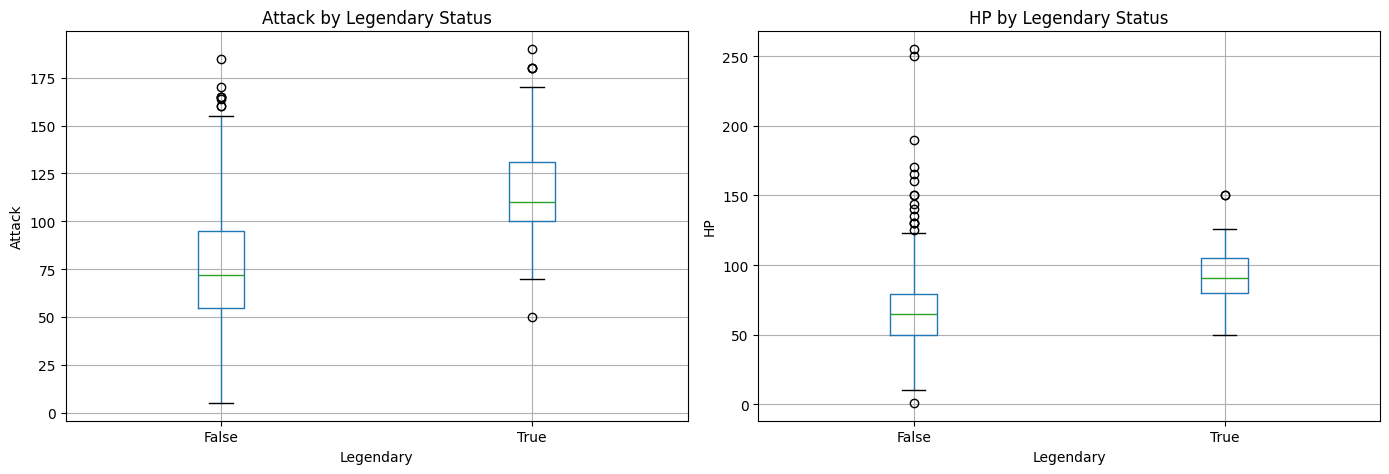

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attack by Legendary status
pokemon.boxplot(column='Attack', by='Legendary', ax=axes[0])
axes[0].set_title('Attack by Legendary Status')
axes[0].set_xlabel('Legendary')
axes[0].set_ylabel('Attack')

# HP by Legendary status
pokemon.boxplot(column='HP', by='Legendary', ax=axes[1])
axes[1].set_title('HP by Legendary Status')
axes[1].set_xlabel('Legendary')
axes[1].set_ylabel('HP')

plt.suptitle('')
plt.tight_layout()
plt.show()


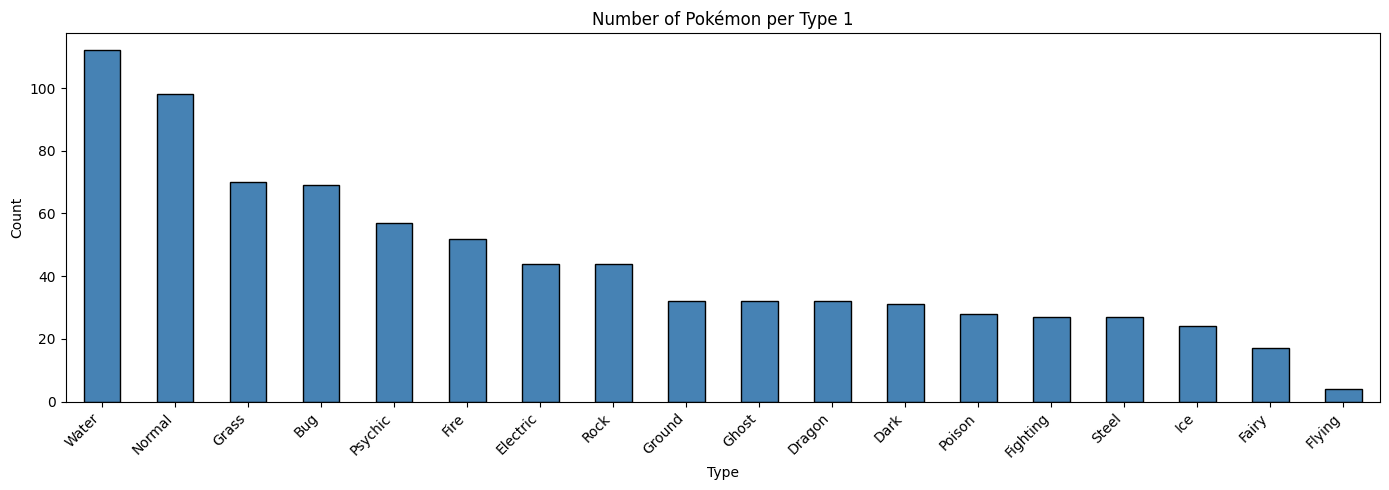

In [ ]:
# Type 1 frequency bar chart
type_counts = pokemon['Type 1'].value_counts()

plt.figure(figsize=(14, 5))
type_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Pokémon per Type 1')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3.4 Tidy Data — `melt()`

`melt()` converts wide-format data into long (tidy) format.  
- `id_vars` — columns to keep as identifiers  
- `value_vars` — columns to melt into rows


In [ ]:
data_new = pokemon.head()

melted = pd.melt(
    frame=data_new,
    id_vars='Name',
    value_vars=['Attack', 'Defense', 'HP', 'Speed']
)
print("Melted shape:", melted.shape)
melted


Melted shape: (20, 3)


,Name,variable,value
0,Bulbasaur,Attack,49
1,Ivysaur,Attack,62
2,Venusaur,Attack,82
3,Mega Venusaur,Attack,100
4,Charmander,Attack,52
5,Bulbasaur,Defense,49
6,Ivysaur,Defense,63
7,Venusaur,Defense,83
8,Mega Venusaur,Defense,123
9,Charmander,Defense,43


## 3.5 Pivoting Data

`pivot()` is the reverse of melting — long → wide.


In [ ]:
melted_2col = pd.melt(frame=data_new, id_vars='Name', value_vars=['Attack', 'Defense'])

pivoted = melted_2col.pivot(index='Name', columns='variable', values='value')
print("Pivoted:")
pivoted


Pivoted:


variable,Attack,Defense
Name,,
Bulbasaur,49,49
Charmander,52,43
Ivysaur,62,63
Mega Venusaur,100,123
Venusaur,82,83


## 3.6 Concatenating Data

`pd.concat()` can join DataFrames **by rows** (`axis=0`) or **by columns** (`axis=1`).


In [ ]:
data1 = pokemon.head()
data2 = pokemon.tail()

# Row concatenation
conc_rows = pd.concat([data1, data2], axis=0, ignore_index=True)
print("Row concat shape:", conc_rows.shape)
conc_rows


Row concat shape: (10, 12)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
5,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
6,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
7,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
8,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
9,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True


In [ ]:
# Column concatenation
col1 = pokemon['Attack'].head()
col2 = pokemon['Defense'].head()

conc_cols = pd.concat([col1, col2], axis=1)
print("Column concat:")
conc_cols


Column concat:


,Attack,Defense
0,49,49
1,62,63
2,82,83
3,100,123
4,52,43


## 3.7 Exploring the Combats Dataset

In [ ]:
combats.head(10)


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151
5,657,752,657
6,192,134,134
7,73,545,545
8,220,763,763
9,302,31,31


Top 10 Pokémon by wins:
              Name  Wins
            Mewtwo   152
        Aerodactyl   136
         Infernape   136
           Jirachi   134
           Slaking   133
Deoxys Speed Forme   133
           Murkrow   130
        Mega Absol   130
     Mega Houndoom   128
   Mega Aerodactyl   127


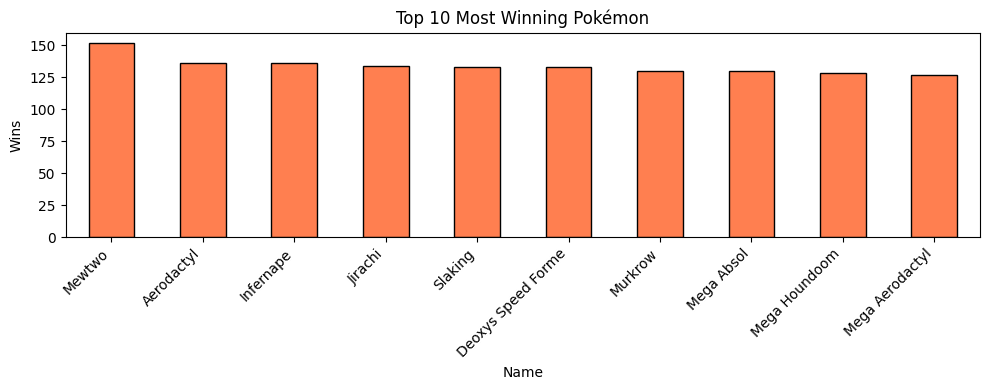

In [ ]:
# Which Pokémon wins the most?
win_counts = combats['Winner'].value_counts().head(10)
win_counts = win_counts.reset_index()
win_counts.columns = ['Pokemon_ID', 'Wins']

# Merge with names
win_counts = win_counts.merge(
    pokemon[['#', 'Name']], left_on='Pokemon_ID', right_on='#', how='left'
)

print("Top 10 Pokémon by wins:")
print(win_counts[['Name', 'Wins']].to_string(index=False))

win_counts.set_index('Name')['Wins'].plot(
    kind='bar', figsize=(10, 4), color='coral', edgecolor='black'
)
plt.title('Top 10 Most Winning Pokémon')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3.8 Data Types & Conversion

Pandas supports: `object`, `bool`, `int64`, `float64`, `category`.  
Converting to `category` saves memory and helps with ML pipelines.


In [ ]:
print("Before conversion:")
print(pokemon.dtypes)


Before conversion:
#             int64
Name            str
Type 1          str
Type 2          str
HP            int64
Attack        int64
Defense       int64
Sp. Atk       int64
Sp. Def       int64
Speed         int64
Generation    int64
Legendary      bool
dtype: object


In [ ]:
# Convert Type 1 → category, Speed → float
pokemon['Type 1'] = pokemon['Type 1'].astype('category')
pokemon['Speed']  = pokemon['Speed'].astype('float')

print("After conversion:")
print(pokemon[['Type 1', 'Speed']].dtypes)


After conversion:
Type 1    category
Speed      float64
dtype: object


## 3.9 Missing Data & Assert Statements

Options when facing NaN values:
1. Leave as-is  
2. **Drop** with `dropna()`  
3. **Fill** with a constant via `fillna()`  
4. **Fill** with a statistic (mean, median)

`assert` lets us verify assumptions — it raises an error if the condition is `False`.


In [ ]:
# How many NaN values per column?
print("NaN counts per column:")
print(pokemon.isnull().sum())


NaN counts per column:
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64


In [ ]:
# Type 2 has the most NaN — let's inspect
print("Type 2 value_counts (including NaN):")
print(pokemon['Type 2'].value_counts(dropna=False))


Type 2 value_counts (including NaN):
Type 2
NaN         386
Flying       97
Ground       35
Poison       34
Psychic      33
Fighting     26
Grass        25
Fairy        23
Steel        22
Dark         20
Dragon       18
Ice          14
Rock         14
Water        14
Ghost        14
Fire         12
Electric      6
Normal        4
Bug           3
Name: count, dtype: int64


In [ ]:
# Strategy 1: fill NaN with 'None' (no secondary type)
pokemon_filled = pokemon.copy()
pokemon_filled['Type 2'] = pokemon_filled['Type 2'].fillna('None')

assert pokemon_filled['Type 2'].notnull().all(), "Still has NaN!"
print("Type 2 NaN filled. Sample:")
print(pokemon_filled['Type 2'].value_counts().head(5))


Type 2 NaN filled. Sample:
Type 2
None       386
Flying      97
Ground      35
Poison      34
Psychic     33
Name: count, dtype: int64


In [ ]:
# Strategy 2: fill numeric NaN with column mean (example on HP)
pokemon_mean = pokemon.copy()
mean_hp = pokemon_mean['HP'].mean()
pokemon_mean['HP'] = pokemon_mean['HP'].fillna(mean_hp)

assert pokemon_mean['HP'].notnull().all(), "HP still has NaN!"
print(f"HP filled with mean={mean_hp:.2f}")
print(f"HP NaN remaining: {pokemon_mean['HP'].isnull().sum()}")


HP filled with mean=69.26
HP NaN remaining: 0


In [ ]:
# Strategy 3: drop rows where Name is NaN
pokemon_dropped = pokemon.copy()
print(f"Rows before drop: {len(pokemon_dropped)}")
pokemon_dropped = pokemon_dropped.dropna(subset=["Name"])
print(f"Rows after drop:  {len(pokemon_dropped)}")

assert pokemon_dropped["Name"].notnull().all()
print("No NaN in Name column - assert passed!")


Rows before drop: 800
Rows after drop:  799
No NaN in Name column - assert passed!


---
# Section 4: Pandas Foundation

## 4.1 Building DataFrames from Scratch


In [ ]:
# From a dictionary
country = ['Ukraine', 'Poland', 'Germany']
population = [44, 38, 84]  # millions

data_dict = {'country': country, 'population_M': population}
df = pd.DataFrame(data_dict)
df


,country,population_M
0,Ukraine,44
1,Poland,38
2,Germany,84


In [ ]:
# Add a new column
df['capital'] = ['Kyiv', 'Warsaw', 'Berlin']

# Broadcasting — single value to entire column
df['continent'] = 'Europe'

df


,country,population_M,capital,continent
0,Ukraine,44,Kyiv,Europe
1,Poland,38,Warsaw,Europe
2,Germany,84,Berlin,Europe


In [ ]:
# zip() usage
list_label = ['country', 'population_M']
list_col   = [country, population]

zipped    = list(zip(list_label, list_col))
data_dict2 = dict(zipped)
df2 = pd.DataFrame(data_dict2)
print("Built with zip():")
df2


Built with zip():


,country,population_M
0,Ukraine,44
1,Poland,38
2,Germany,84


## 4.2 Visual EDA — Plots, Subplots, Histograms

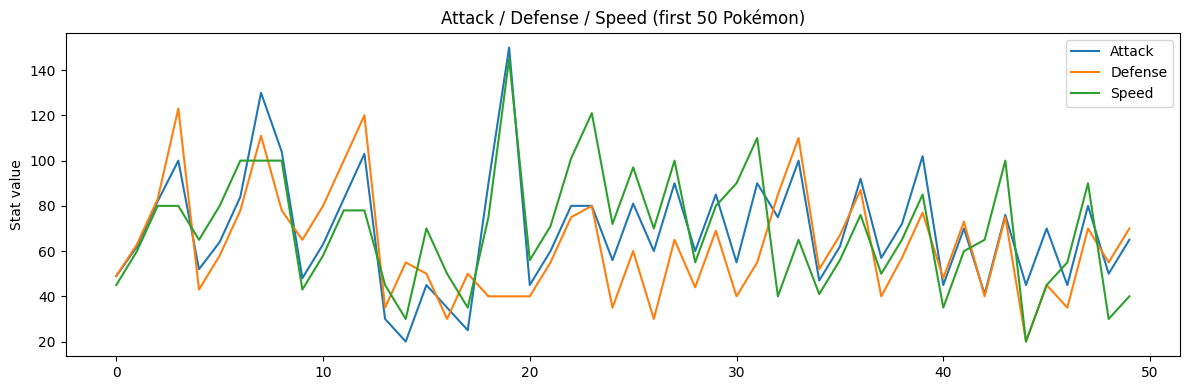

In [ ]:
# Select numeric combat-relevant columns
data_plot = pokemon.loc[:, ['Attack', 'Defense', 'Speed']]

# Line plot (all columns together — messy but illustrative)
data_plot.head(50).plot(figsize=(12, 4), title='Attack / Defense / Speed (first 50 Pokémon)')
plt.ylabel('Stat value')
plt.tight_layout()
plt.show()


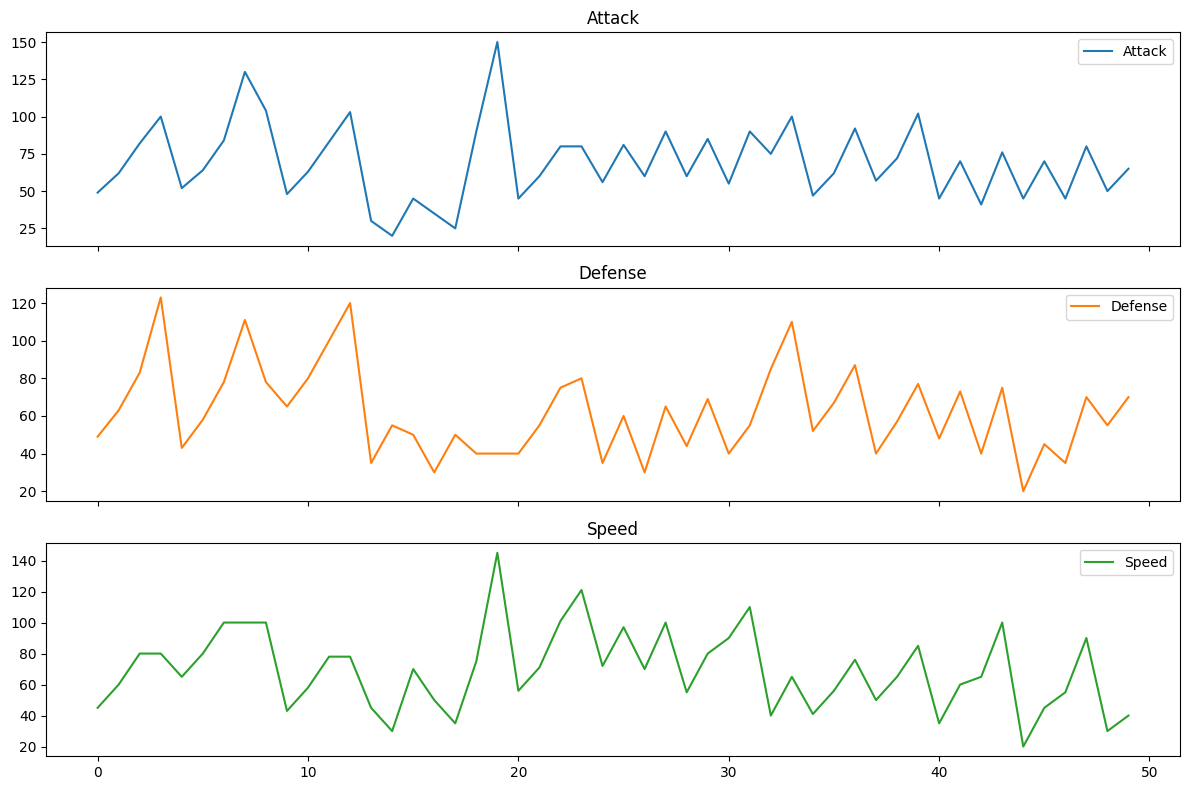

In [ ]:
# Subplots
data_plot.head(50).plot(subplots=True, figsize=(12, 8),
                        title=['Attack', 'Defense', 'Speed'])
plt.tight_layout()
plt.show()


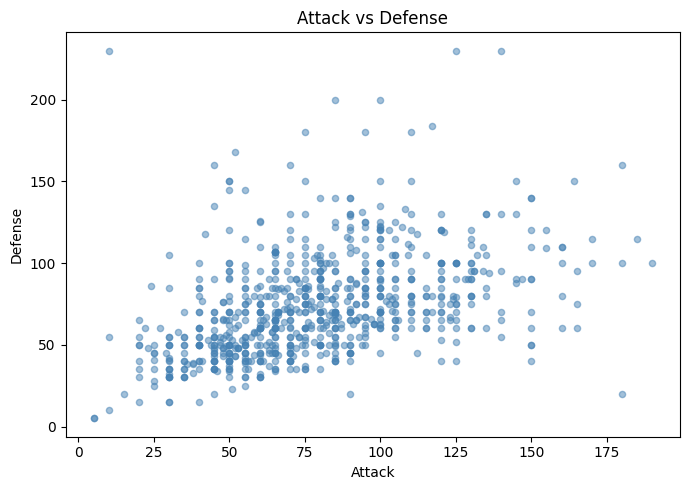

In [ ]:
# Scatter plot
data_plot.plot(kind='scatter', x='Attack', y='Defense',
               figsize=(7, 5), alpha=0.5, color='steelblue')
plt.title('Attack vs Defense')
plt.tight_layout()
plt.show()


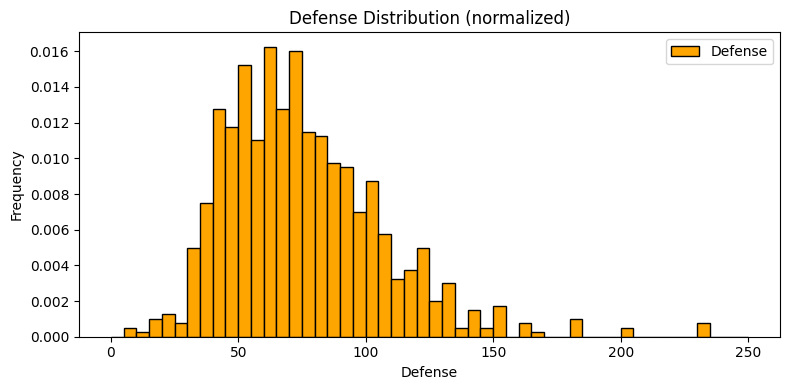

In [ ]:
# Histogram — Defense distribution
data_plot.plot(kind='hist', y='Defense', bins=50,
               range=(0, 250), density=True, figsize=(8, 4),
               color='orange', edgecolor='black')
plt.title('Defense Distribution (normalized)')
plt.xlabel('Defense')
plt.tight_layout()
plt.show()


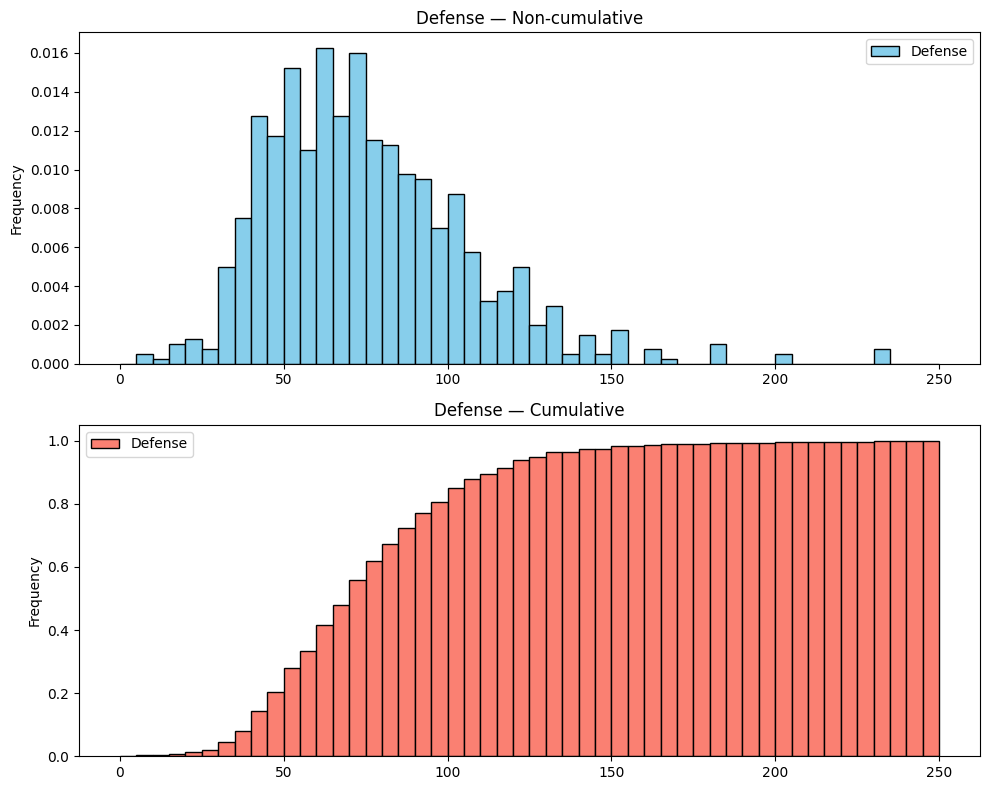

In [ ]:
# Non-cumulative vs cumulative histogram side-by-side
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

data_plot.plot(kind='hist', y='Defense', bins=50, range=(0, 250),
               density=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Defense — Non-cumulative')

data_plot.plot(kind='hist', y='Defense', bins=50, range=(0, 250),
               density=True, ax=axes[1], cumulative=True,
               color='salmon', edgecolor='black')
axes[1].set_title('Defense — Cumulative')

plt.tight_layout()
plt.show()


## 4.3 Statistical EDA — `describe()`

In [ ]:
pokemon.describe()


,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


         Legendary_mean  NonLegendary_mean
HP            92.738462          67.182313
Attack       116.676923          75.669388
Defense       99.661538          71.559184
Speed        100.184615          65.455782


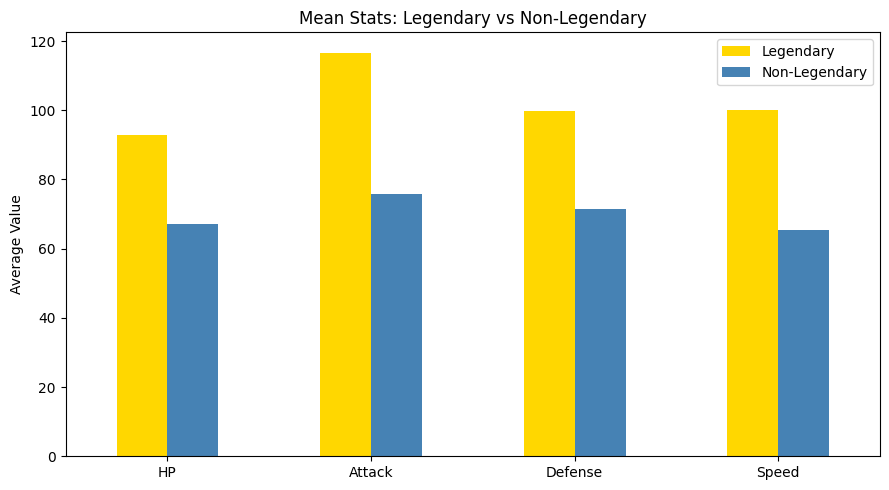

In [ ]:
# Compare legendary vs non-legendary stats
legendary     = pokemon[pokemon['Legendary'] == True]
non_legendary = pokemon[pokemon['Legendary'] == False]

stats = pd.DataFrame({
    'Legendary_mean':     legendary[['HP','Attack','Defense','Speed']].mean(),
    'NonLegendary_mean':  non_legendary[['HP','Attack','Defense','Speed']].mean(),
})
print(stats)

stats.plot(kind='bar', figsize=(9, 5), color=['gold', 'steelblue'])
plt.title('Mean Stats: Legendary vs Non-Legendary')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(['Legendary', 'Non-Legendary'])
plt.tight_layout()
plt.show()


## 4.4 Indexing Pandas Time Series

In [ ]:
time_list = ['1992-03-08', '1992-04-12']
print("Before:", type(time_list[0]))

datetime_object = pd.to_datetime(time_list)
print("After:", type(datetime_object))


Before: <class 'str'>
After: <class 'pandas.DatetimeIndex'>


In [ ]:
# Attach date index to first 5 Pokémon
data2 = pokemon.head().copy()
date_list = ['1992-01-10','1992-02-10','1992-03-10','1993-03-15','1993-03-16']
data2['date'] = pd.to_datetime(date_list)
data2 = data2.set_index('date')

print("Data with datetime index:")
data2[['Name', 'HP', 'Attack']]


Data with datetime index:


,Name,HP,Attack
date,,,
1992-01-10,Bulbasaur,45,49
1992-02-10,Ivysaur,60,62
1992-03-10,Venusaur,80,82
1993-03-15,Mega Venusaur,80,100
1993-03-16,Charmander,39,52


In [ ]:
# Slice by date
print("Single date 1993-03-16:")
print(data2.loc["1993-03-16"][["Name","Attack"]])

print("Range 1992-03-10 to 1993-03-16:")
print(data2.loc["1992-03-10":"1993-03-16"][["Name","Attack"]])


Single date 1993-03-16:
Name      Charmander
Attack            52
Name: 1993-03-16 00:00:00, dtype: object
Range 1992-03-10 to 1993-03-16:
                     Name  Attack
date                             
1992-03-10       Venusaur      82
1993-03-15  Mega Venusaur     100
1993-03-16     Charmander      52


## 4.5 Resampling Time Series

- **Downsampling** — slower frequency (e.g., daily → monthly)  
- **Upsampling** — faster frequency (e.g., monthly → daily)  
- **Interpolation** — fill gaps created by upsampling


In [ ]:
# Resample by year
print("Resample by Year (mean):")
data2[['HP','Attack','Defense']].resample('YE').mean()


Resample by Year (mean):


,HP,Attack,Defense
date,,,
1992-12-31,61.666667,64.333333,65.0
1993-12-31,59.500000,76.000000,83.0


In [ ]:
# Resample by month with linear interpolation
monthly = data2[['HP','Attack','Defense']].resample('ME').mean()
monthly_interp = monthly.interpolate('linear')

print("Monthly resampled (interpolated):")
monthly_interp


Monthly resampled (interpolated):


,HP,Attack,Defense
date,,,
1992-01-31,45.000000,49.0,49.0
1992-02-29,60.000000,62.0,63.0
1992-03-31,80.000000,82.0,83.0
1992-04-30,78.291667,81.5,83.0
1992-05-31,76.583333,81.0,83.0
1992-06-30,74.875000,80.5,83.0
1992-07-31,73.166667,80.0,83.0
1992-08-31,71.458333,79.5,83.0
1992-09-30,69.750000,79.0,83.0


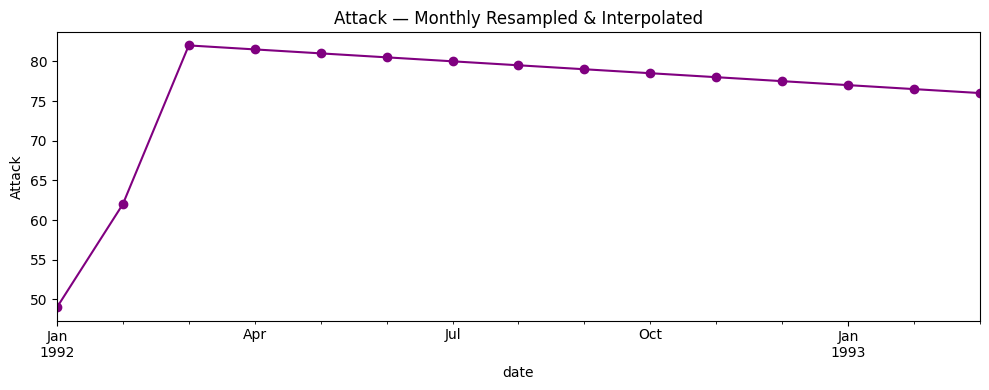

In [ ]:
# Plot interpolated Attack over time
monthly_interp['Attack'].plot(
    figsize=(10, 4), marker='o', color='purple',
    title='Attack — Monthly Resampled & Interpolated'
)
plt.ylabel('Attack')
plt.tight_layout()
plt.show()


---
## Summary

### Section 3 — Cleaning Data
| Topic | Method |
|---|---|
| Diagnose data | `head()`, `tail()`, `info()`, `shape`, `columns` |
| EDA | `value_counts()`, `describe()` |
| Visual EDA | `boxplot()`, bar charts |
| Tidy data | `melt()` |
| Pivot | `pivot()` |
| Concatenate | `pd.concat()` |
| Data types | `astype('category')`, `astype('float')` |
| Missing data | `isnull()`, `dropna()`, `fillna()` |
| Assert | `assert df.col.notnull().all()` |

### Section 4 — Pandas Foundation
| Topic | Method |
|---|---|
| Build DataFrame | from dict, `zip()` |
| Add column | `df['col'] = value` (broadcasting) |
| Plots | `.plot()`, subplots, hist, scatter |
| Statistics | `describe()` |
| Datetime | `pd.to_datetime()`, `.set_index()` |
| Resample | `.resample('M')`, `.resample('A')` |
| Interpolate | `.interpolate('linear')` |
